# Figure 1 and S1 Bleo/Blast and puro selection

Notes:

1. Singlets
2. Infected EF1a-Nb(EGFP)-anti-TagBFP-P2A-iRFP670-WPRE


Selection protocol:
1. Infect in suspension with MOI 5 at 20k/96-well
2. After at least 2 dpi, reseed at 20k/96-well into antibiotic
3. Refresh antibiotic after 2 days with treatment, 4 dpt, then flow on 6 dpt. Kept blast and bleo going until 10 dpt.

In [2]:
import pandas as pd
import numpy as np
import re
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
import seaborn as sns
from statannotations.Annotator import Annotator
import rushd as rd
import matplotlib
from scipy.optimize import curve_fit
from scipy.stats import poisson
from scipy.optimize import fsolve

# Load data

Directories for all

In [5]:
# Directories 
output_path = rd.rootdir/'output'/'Figure_S1_blast_bleo'
output_path = rd.rootdir/'output'/'Figure_1_blast_bleo_puro'
cache_path = rd.rootdir/'output'/'Figure_S1_blast_bleo'/'data.gzip'
datadir = rd.datadir /'data'/ 'attune'/ "nat_attune" / "desNb-circuits" # Fig path

Load in puro data

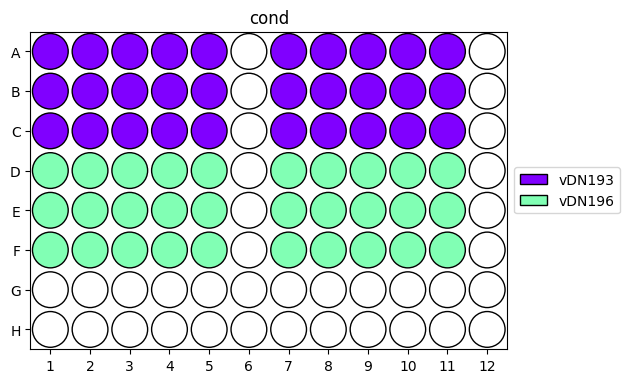

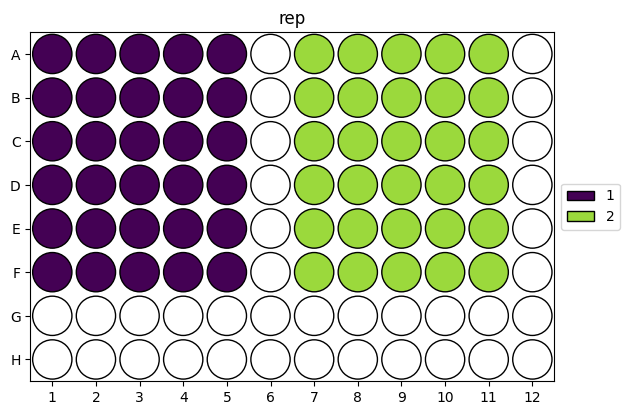

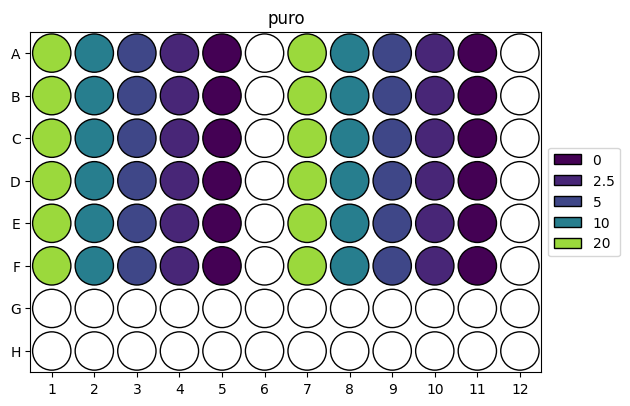

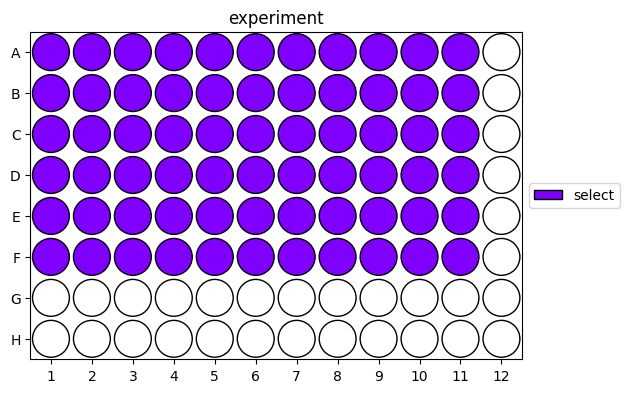

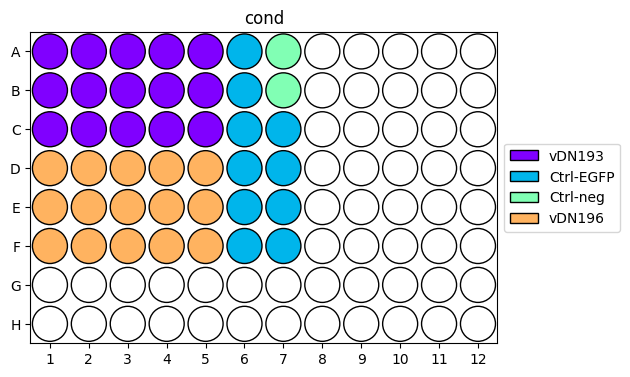

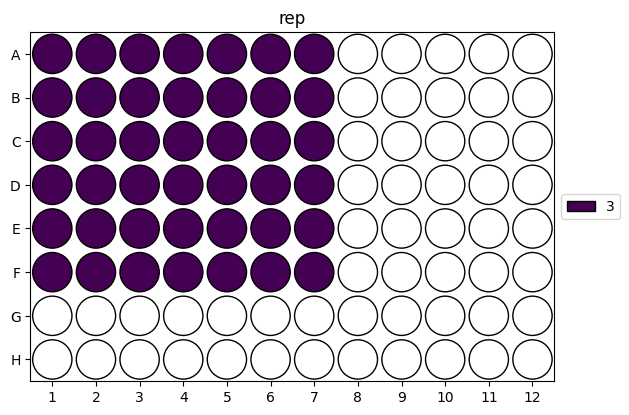

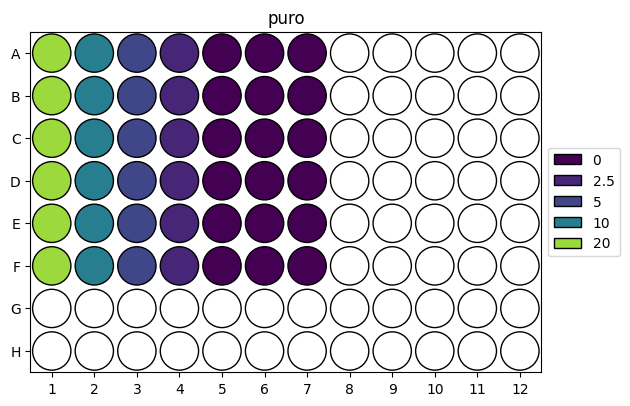

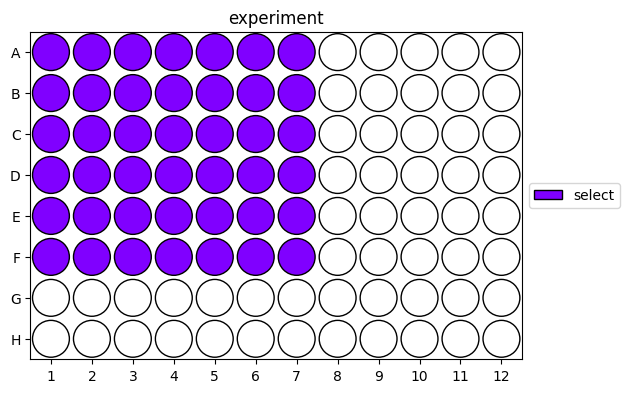

In [6]:
# Data path
puro_path = '2025.12.15_vDN193-196-select_6dpt'
puro_cache_path = rd.rootdir/'output'/'Figure_S1_blast_bleo'/'data.gzip'
# puro_cache_path = datadir / puro_path / '2025.12.15_vDN193-196-select_6dpt_1' / 'export_singlets' /'data_7dpi.gzip'

if puro_cache_path.exists():
    df_puro = pd.read_parquet(puro_cache_path)

else: 
    
    # Load plate 1 
    path_1 = datadir / puro_path / '2025.12.15_vDN193-196-select_6dpt_1'
    df_puro_1 = rd.flow.load_csv_with_metadata(path_1/'export_singlets', path_1/'2025.12.15_vDN193-196-select_6dpt_1.yaml')
    rd.plot.plot_well_metadata(path_1/'2025.12.15_vDN193-196-select_6dpt_1.yaml')

    # Load plate 2
    path_2 = datadir / puro_path / '2025.12.15_vDN193-196-select_6dpt_2'
    df_puro_2 = rd.flow.load_csv_with_metadata(path_2/'export_singlets', path_2/'2025.12.15_vDN193-196-select_6dpt_2.yaml')
    rd.plot.plot_well_metadata(path_2/'2025.12.15_vDN193-196-select_6dpt_2.yaml')

    # Convert list of dfs into single df
    df_puro = pd.concat([df_puro_1, df_puro_2], ignore_index=True)

    # Shorten df
    channel_list = ['experiment', 'cond', 'rep', 'well', 'puro', 'eGFP-A', 'eGFP-H', 'iRFP670-A','iRFP670-H', 'mRuby2-A', 'mRuby2-H', 'TagBFP-A', 'TagBFP-H',]
    df_puro = df_puro.loc[:, channel_list]

    # Add blast and zeo is 0
    df_puro.loc[:, 'blast'] = 0
    df_puro.loc[:, 'zeo'] = 0
    df_puro.loc[:, 'dpt'] = 6


    # Save shortened df
    df_puro.to_parquet(rd.outfile(puro_cache_path))

**Load in puro data for new experiment**

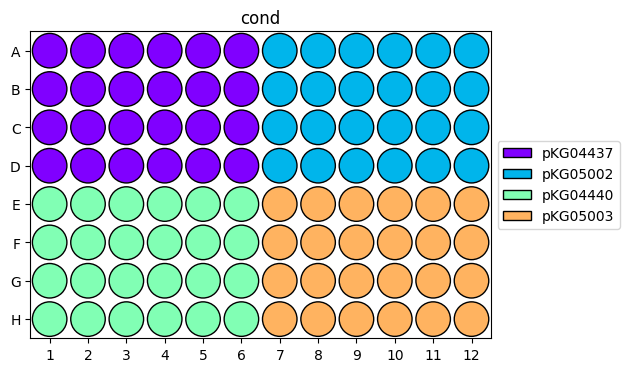

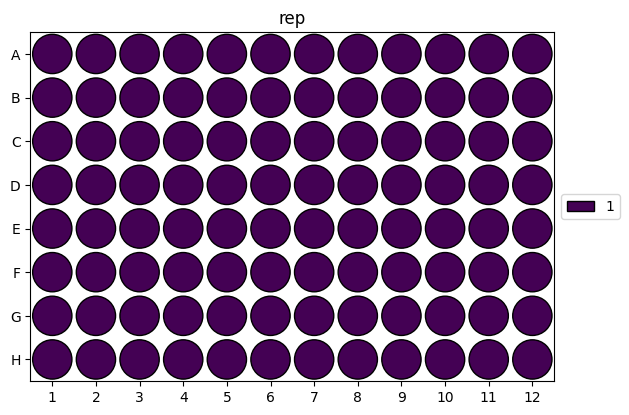

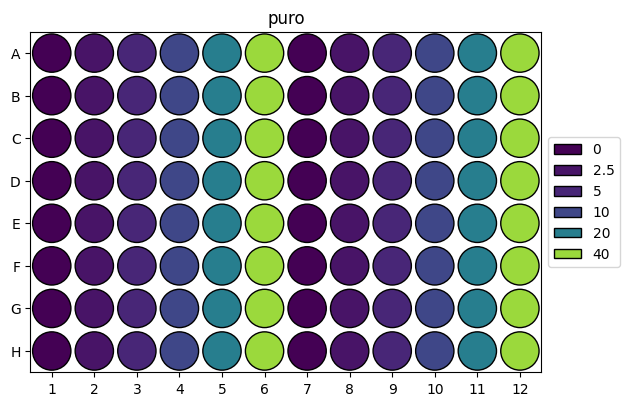

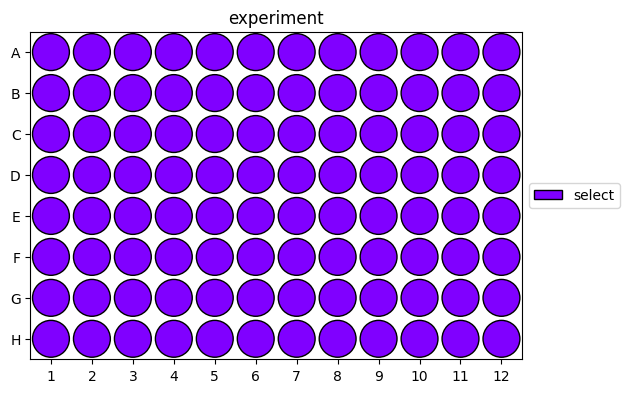

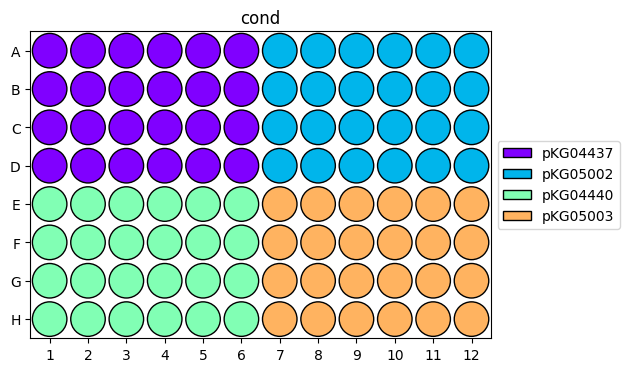

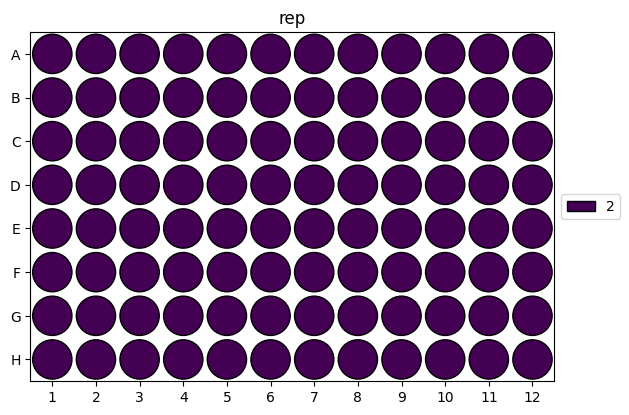

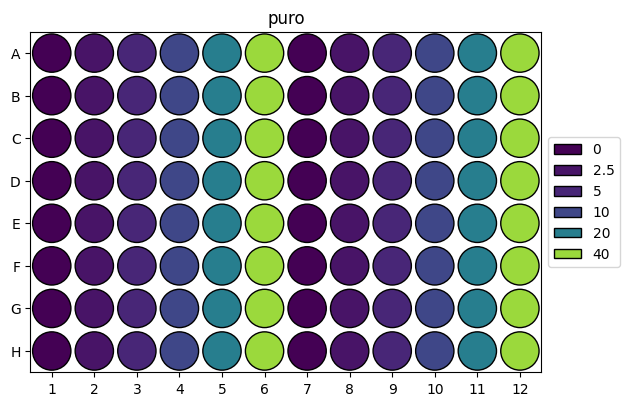

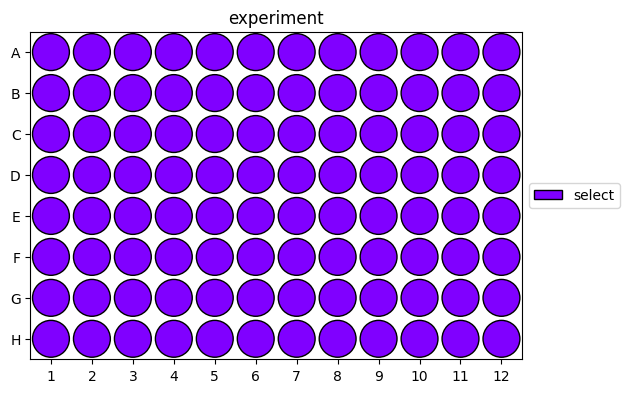

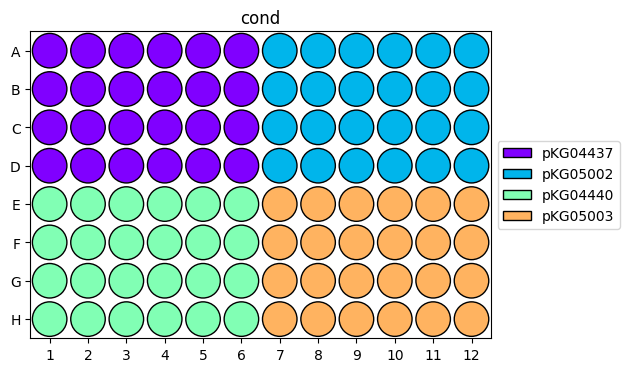

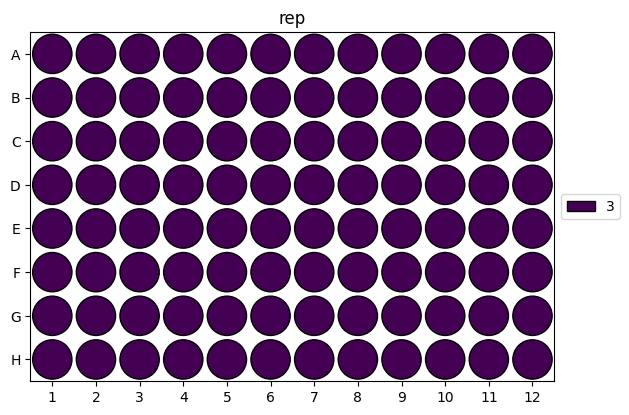

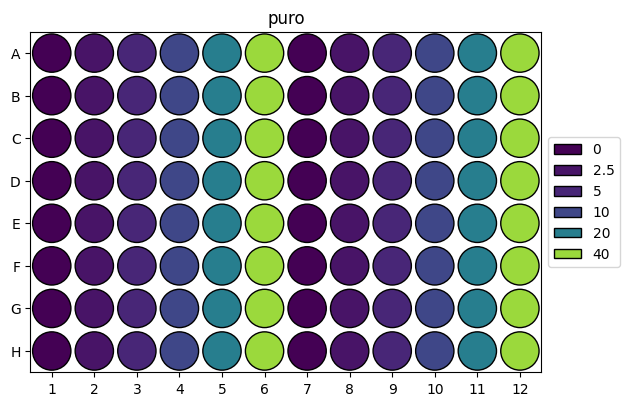

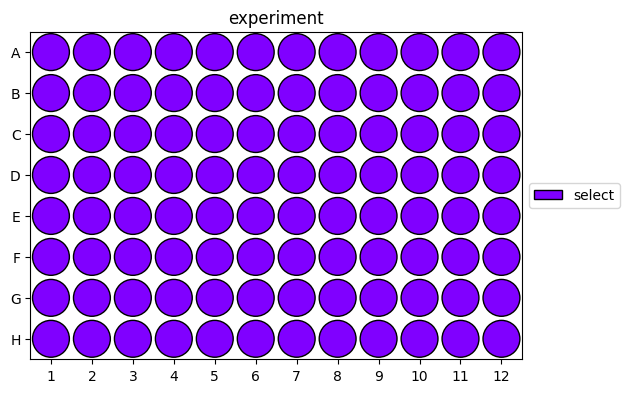

In [12]:
# Data path
datadir = rd.datadir /'data'/ 'attune'/ "Mary" / "2026.06.03_exp47" # Fig path
puro_cache_path = rd.rootdir/'output'/'Figure_S1_blast_bleo'/'data.gzip'
# puro_cache_path = datadir / puro_path / '2025.12.15_vDN193-196-select_6dpt_1' / 'export_singlets' /'data_7dpi.gzip'

if puro_cache_path.exists():
    df_puro = pd.read_parquet(puro_cache_path)

else: 
    
    # Load plate 1 
    path_1 = datadir / 'Plate1'
    df_puro_1 = rd.flow.load_csv_with_metadata(path_1/'export_singlets', datadir/'2025.12.15_vDN193-196-select_6dpt_rep1.yaml')
    rd.plot.plot_well_metadata(datadir/'2025.12.15_vDN193-196-select_6dpt_rep1.yaml')

    # Load plate 2
    path_2 = datadir / 'Plate2'
    df_puro_2 = rd.flow.load_csv_with_metadata(path_2/'export_singlets', datadir/'2025.12.15_vDN193-196-select_6dpt_rep2.yaml')
    rd.plot.plot_well_metadata(datadir/'2025.12.15_vDN193-196-select_6dpt_rep2.yaml')

    # Load plate 2
    path_3 = datadir / 'Plate3'
    df_puro_3 = rd.flow.load_csv_with_metadata(path_2/'export_singlets', datadir/'2025.12.15_vDN193-196-select_6dpt_rep3.yaml')
    rd.plot.plot_well_metadata(datadir/'2025.12.15_vDN193-196-select_6dpt_rep3.yaml')

    # Convert list of dfs into single df
    df_puro = pd.concat([df_puro_1, df_puro_2, df_puro_3], ignore_index=True)

    # Shorten df
    channel_list = ['experiment', 'cond', 'rep', 'well', 'puro', 'mGL-A', 'mGL-H', 'iRFP670-A','iRFP670-H', 'mRuby2-A', 'mRuby2-H', 'TagBFP-A', 'TagBFP-H',]
    df_puro = df_puro.loc[:, channel_list]

    # Add blast and zeo is 0
    df_puro.loc[:, 'blast'] = 0
    df_puro.loc[:, 'zeo'] = 0
    df_puro.loc[:, 'dpt'] = 6


    # Save shortened df
    df_puro.to_parquet(rd.outfile(puro_cache_path))

**Rename mGL-A and mGL-H columns to eGFP-A and eGFP-H**

In [13]:
df_puro = df_puro.rename(columns={'mGL-A': 'eGFP-A', 'mGL-H': 'eGFP-H'})

Load in blast and bleo data

In [7]:
# Data path
blastbleo_path = datadir / '2025.12.15_vDN194-195-select' / '2025.12.15_vDN194-195-select_6dpt'
blastlet_cache_path = datadir / blastbleo_path / 'data.gzip'

if blastlet_cache_path.exists():
    df_blastbleo = pd.read_parquet(blastlet_cache_path)

else: 
    df_blastbleo = rd.flow.load_csv_with_metadata(blastbleo_path/'export_singlets', blastbleo_path/'metadata.yaml')
    rd.plot.plot_well_metadata(blastbleo_path/'metadata.yaml')

    # Shorten df
    channel_list = ['experiment', 'dpt', 'cond', 'rep', 'well', 'blast', 'zeo', 'eGFP-A', 'eGFP-H', 'iRFP670-A','iRFP670-H', 'mRuby2-A', 'mRuby2-H', 'TagBFP-A', 'TagBFP-H',]
    df_blastbleo = df_blastbleo.loc[:, channel_list]

    # Add puro is 0
    df_blastbleo.loc[:, 'puro'] = 0

    # Save shortened df
    df_blastbleo.to_parquet(rd.outfile(blastlet_cache_path))

In [8]:
# Data path
blastbleo_path_2 = datadir / '2025.12.15_vDN194-195-select' / '2025.12.19_vDN194-195-select'
blastlet_cache_path_2 = datadir / blastbleo_path_2 / 'data.gzip'

if blastlet_cache_path_2.exists():
    df_blastbleo_2 = pd.read_parquet(blastlet_cache_path_2)

else: 
    df_blastbleo_2 = rd.flow.load_csv_with_metadata(blastbleo_path_2/'export_singlets', blastbleo_path_2/'metadata.yaml')
    rd.plot.plot_well_metadata(blastbleo_path_2/'metadata.yaml')

    # Shorten df
    channel_list = ['experiment', 'dpt', 'cond', 'rep', 'well', 'blast', 'zeo', 'eGFP-A', 'eGFP-H', 'iRFP670-A','iRFP670-H', 'mRuby2-A', 'mRuby2-H', 'TagBFP-A', 'TagBFP-H',]
    df_blastbleo_2 = df_blastbleo_2.loc[:, channel_list]

    # Add puro is 0
    df_blastbleo_2.loc[:, 'puro'] = 0

    # Save shortened df
    df_blastbleo_2.to_parquet(rd.outfile(blastlet_cache_path_2))

Combine df

In [14]:
df_all = pd.concat([df_puro, df_blastbleo, df_blastbleo_2], ignore_index=True)

In [15]:
display(df_all)

,experiment,cond,rep,well,puro,eGFP-A,eGFP-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,TagBFP-A,TagBFP-H,blast,zeo,dpt
0,select,pKG05002,1,A10,10.0,114.0,89.0,20199.0,17256.0,90.0,186.0,51.0,84.0,0,0,6
1,select,pKG05002,1,A10,10.0,-78.0,80.0,17792.0,13077.0,-66.0,70.0,-14.0,58.0,0,0,6
2,select,pKG05002,1,A10,10.0,66680.0,48986.0,46504.0,37146.0,23058.0,17791.0,570.0,381.0,0,0,6
3,select,pKG05002,1,A10,10.0,67.0,50.0,10007.0,8310.0,167.0,204.0,255.0,141.0,0,0,6
4,select,pKG05002,1,A10,10.0,78.0,63.0,17562.0,14627.0,225.0,235.0,155.0,151.0,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27357494,select,vDN195,1,A3,0.0,66194.0,45195.0,16919.0,11755.0,325.0,297.0,28972.0,19145.0,0,1000,10
27357495,select,vDN195,1,A3,0.0,75376.0,53879.0,19926.0,14536.0,144.0,147.0,34417.0,23984.0,0,1000,10
27357496,select,vDN195,1,A3,0.0,-223.0,45.0,31350.0,21663.0,469.0,366.0,9007.0,5750.0,0,1000,10
27357497,select,vDN195,1,A3,0.0,54827.0,40877.0,13671.0,10350.0,281.0,205.0,21965.0,15774.0,0,1000,10


# Gating for integrated cells

## Gate infection marker

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 2))

# Threshold for iRFP670
iRFP670_H_thresh = 2.5e2

# Plot iRFP670-H
x = 'iRFP670-H'
hue = 'cond'
hue_order = ['pKG04437', 'vDN194', 'vDN195', 'pKG04440']


sns.kdeplot(data=df_all.loc[(df_all.puro == 0) & (df_all.zeo == 0) & (df_all.blast == 0) & (df_all[x] > 0) & (df_all.cond != 'Ctrl-neg') ],
        ax=ax, x=x, hue=hue,
        hue_order=hue_order,
        common_norm=False, log_scale=(True, False),
        fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=df_all.loc[(df_all.cond=='Ctrl-neg')& (df_all[x] > 0)],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey', legend=False)
ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(iRFP670_H_thresh, 0, 1, color='black')


# Title
plt.title('6 dpt, 293T, Ctrl')
# Adjust limits
mRuby2_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(mRuby2_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'dist-iRFP670.svg', bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

In [ ]:
# Categorize cells based on iRFP670_thresh
df_all.loc[:, 'iRFP670_cat'] = 'iRFP670-'
df_all.loc[(df_all['iRFP670-H'] > iRFP670_H_thresh), 'iRFP670_cat'] = 'iRFP670+'

# Get total counts and percent of GFP-H+
group = [ 'experiment', 'cond', 'rep', 'dpt', 'blast', 'zeo', 'puro']
count_df_reps = df_all.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=lo

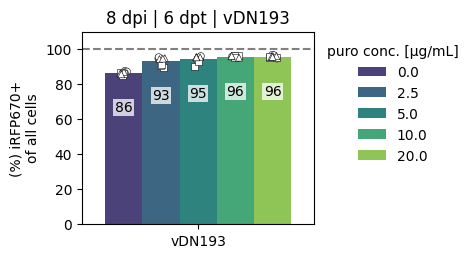

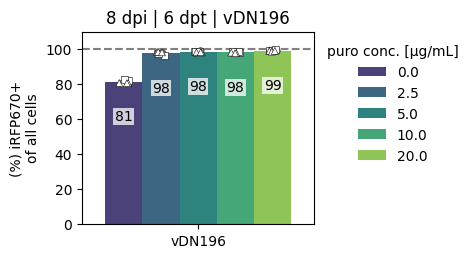

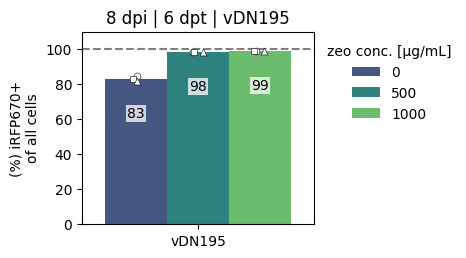

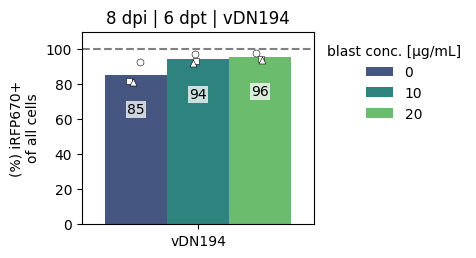

In [ ]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

antibiotic_map = {'pKG04437':'puro', 'vDN194':'blast', 'vDN195':'zeo', 'pKG04440':'puro'}


for cond in df_all.cond.unique():

    if (cond=='Ctrl-neg') | (cond=='Ctrl-EGFP'): continue

    curr_df = data_iRFP670_percent_reps[data_iRFP670_percent_reps.cond == cond]
    curr_df = curr_df.loc[curr_df['dpt'] == 6]

    hue = antibiotic_map[cond]
    hue_order = np.sort(curr_df[hue].unique())

    # What to plot
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

    # Plot
    sns.barplot(
        ax=ax, data=curr_df,
        x=x, y=y, ci=None, hue=hue,
        palette="viridis", alpha=1)
    
    # Plot tech reps
    for (j, rep) in enumerate(curr_df.rep.unique()):
        sns.stripplot(
            ax=ax, data=curr_df[(curr_df.rep == rep)],
            x=x, y=y, hue=hue,
            dodge=True, marker=marker_list[j],
            palette={puro:'white' for puro in hue_order}, size=5,
            edgecolor='black', linewidth=0.4,)

    # Formatting
    ax.yaxis.set_label_text('(%) iRFP670+\nof all cells')
    ax.set_ylim((0, 110))
    h,l = ax.get_legend_handles_labels()
    sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
        title=f'{hue} conc. [µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    # Title
    ax.set_title(f'8 dpi | 6 dpt | {cond}')
    ax.axhline(100, 0, 1, color='grey', linestyle='--')
    ax.set_xlabel('')
    # Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-30)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
    # 
    # plt.savefig(figpath + f'bar_iRFP670-percent_{cond}.svg', bbox_inches='tight')

## EGFP purity

**Figure S1A - eGFP Distribution**

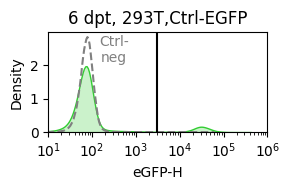

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Threshold for GFP
eGFP_H_thresh = 3*10**3

# Plot eGFP-H
x = 'eGFP-H'

# Plot Ctrl-EGFP
cond = 'Ctrl-EGFP'
sns.kdeplot(data=df_all.loc[(df_all['cond'] == cond) & (df_all[x] > 0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False), color='limegreen',
        fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=df_all.loc[(df_all.cond=='Ctrl-neg')& (df_all[x] > 0)],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey', legend=False)
ax.annotate('Ctrl-\nneg', (0.3, 0.7), color='grey', xycoords='axes fraction', ha='center')


# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'6 dpt, 293T,{cond}')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'dist-eGFP.svg', bbox_inches='tight')

In [112]:
# Categorize cells based on eGFP_thresh
df_all.loc[:, 'eGFP_cat'] = 'eGFP-'
df_all.loc[(df_all['eGFP-H'] > eGFP_H_thresh), 'eGFP_cat'] = 'eGFP+'

# Gate infected cells
df_infected = df_all.loc[(df_all['iRFP670_cat'] == 'iRFP670+')]

# Get total counts and percent of GFP-H+ of the infected cells
group = [ 'experiment', 'cond', 'rep', 'dpt', 'blast', 'zeo', 'puro']
count_df_reps = df_infected.groupby([*group, 'well', 'eGFP_cat'])[
    'eGFP-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps = data_eGFP_count_reps.loc[(data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=lo

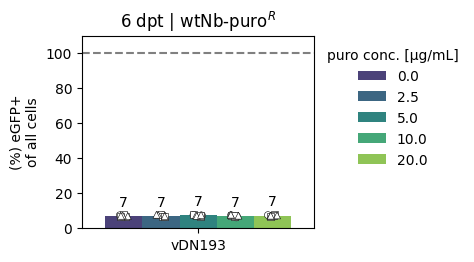

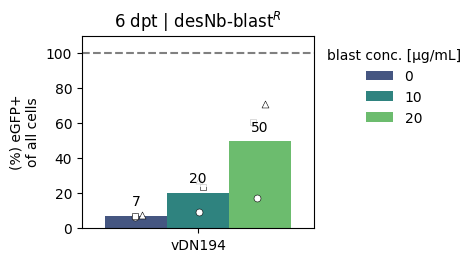

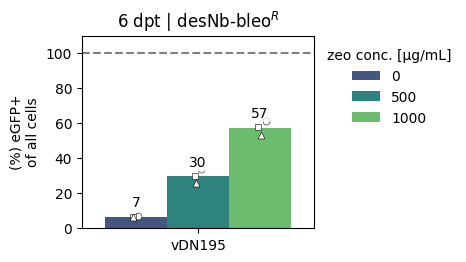

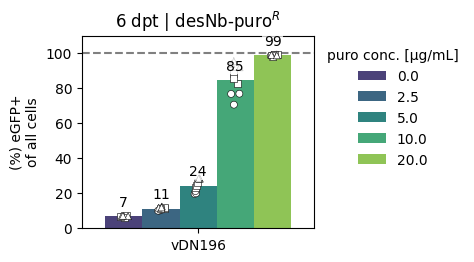

In [113]:
# General plotting params
x = 'cond'
y = 'percent'
dpt = 6
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

antibiotic_map = {'vDN193':'puro', 'vDN194':'blast', 'vDN195':'zeo', 'vDN196':'puro'}
label_map = {'vDN193':'wtNb-puro$^R$', 'vDN194':'desNb-blast$^R$', 'vDN195':'desNb-bleo$^R$', 'vDN196':'desNb-puro$^R$'}


for cond in data_eGFP_percent_reps.cond.unique():

    if (cond=='Ctrl-neg') | (cond=='Ctrl-EGFP'): continue

    curr_df = data_eGFP_percent_reps.loc[(data_eGFP_percent_reps.cond == cond) & (data_eGFP_percent_reps.dpt == dpt)]

    hue = antibiotic_map[cond]
    hue_order = np.sort(curr_df[hue].unique())
    

    # What to plot
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

    # Plot
    sns.barplot(
        ax=ax, data=curr_df,
        x=x, y=y, ci=None, hue=hue,
        palette="viridis", alpha=1)
    
    # Plot tech reps
    for (j, rep) in enumerate(curr_df.rep.unique()):
        sns.stripplot(
            ax=ax, data=curr_df[(curr_df.rep == rep)],
            x=x, y=y, hue=hue,
            dodge=True, marker=marker_list[j],
            palette={puro:'white' for puro in hue_order}, size=5,
            edgecolor='black', linewidth=0.4,)

    # Formatting
    ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
    ax.set_ylim((0, 110))
    h,l = ax.get_legend_handles_labels()
    sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
        title=f'{hue} conc. [µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    # Title
    ax.set_title(f'6 dpt | {label_map[cond]}')
    ax.axhline(100, 0, 1, color='grey', linestyle='--')
    ax.set_xlabel('')
    # Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
    
    # plt.savefig(figpath + f'bar_EGFP-percent_{cond}_{dpt}dpt.svg', bbox_inches='tight')

### Plot just wtNb vs. desNb

Purity

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


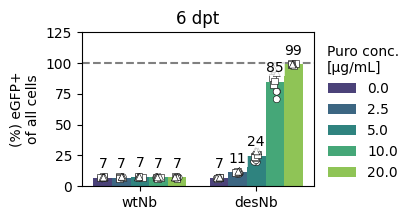

In [114]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['vDN193', 'vDN196']
label_map = {'vDN193':'wtNb', 'vDN196':'desNb'}

df_curr = data_eGFP_percent_reps.loc[(data_eGFP_percent_reps.cond == 'vDN193') | (data_eGFP_percent_reps.cond == 'vDN196')]
df_curr = df_curr.loc[df_curr.dpt == 6]

hue = 'puro'
hue_order = np.sort(data_eGFP_percent_reps[hue].unique())

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,
    order=order,
    palette="viridis", alpha=1)


# Plot tech reps
for (j, rep) in enumerate(df_curr.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.rep == rep)],
        x=x, y=y, hue=hue,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro:'white' for puro in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,)
    



# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 125))
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
    title=f'Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
# Title
ax.set_title(f'6 dpt')
ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels([label_map[l] for l in order])
# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))

# plt.savefig(figpath + f'bar_EGFP-percent_puro-ONLY.svg', bbox_inches='tight')

Counts

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


Text(0.5, 0, '')

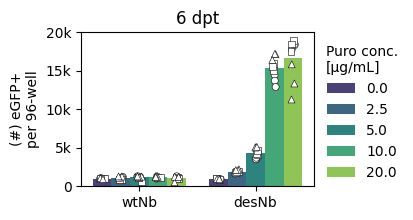

In [115]:
# General plotting params
x = 'cond'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['vDN193', 'vDN196']
label_map = {'vDN193':'wtNb', 'vDN196':'desNb'}

df_curr = data_eGFP_count_reps.loc[(data_eGFP_count_reps.cond == 'vDN193') | (data_eGFP_count_reps.cond == 'vDN196')]
df_curr = df_curr.loc[df_curr.dpt == 6]

hue = 'puro'
hue_order = np.sort(data_eGFP_count_reps[hue].unique())

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,
    order=order,
    palette="viridis", alpha=1)


# Plot tech reps
for (j, rep) in enumerate(df_curr.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.rep == rep)],
        x=x, y=y, hue=hue,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro:'white' for puro in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,)


 # Formatting
ax.yaxis.set_label_text('(#) eGFP+\nper 96-well')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 20e3))
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
    title=f'Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    
# Title
ax.set_title(f'6 dpt')
ax.set_xlabel('')

# plt.savefig(figpath + f'bar_EGFP-count_puro-ONLY.svg', bbox_inches='tight')


In [121]:
# Get total counts and percent of all the infected cells
group = [ 'experiment', 'cond', 'rep', 'dpt', 'blast', 'zeo', 'puro']
count_df_reps = df_infected.groupby([*group, 'well'])[
    'eGFP-H'].count().rename('count').reset_index(name='count') # Puts 0 if no GFP-H+ rather than dropping row
# percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
# data_eGFP_count_reps = count_df_reps.reset_index()

# # Extract just the eGFP+
# data_eGFP_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'eGFP+')]
# data_eGFP_count_reps = data_eGFP_count_reps.loc[(data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]
count_df_reps

,experiment,cond,rep,dpt,blast,zeo,puro,well,count
0,select,Ctrl-EGFP,1,10,0,0,0.0,A7,23
1,select,Ctrl-EGFP,2,10,0,0,0.0,B7,21
2,select,Ctrl-EGFP,3,6,0,0,0.0,A6,14214
3,select,Ctrl-EGFP,3,6,0,0,0.0,B6,15158
4,select,Ctrl-EGFP,3,6,0,0,0.0,C6,15603
...,...,...,...,...,...,...,...,...,...
136,select,vDN196,3,6,0,0,10.0,E2,18014
137,select,vDN196,3,6,0,0,10.0,F2,17850
138,select,vDN196,3,6,0,0,20.0,D1,11523
139,select,vDN196,3,6,0,0,20.0,E1,13475


In [124]:
df_curr

,experiment,cond,rep,dpt,blast,zeo,puro,well,count
15,select,vDN193,1,6,0,0,0.0,A5,15372
16,select,vDN193,1,6,0,0,0.0,B5,14748
17,select,vDN193,1,6,0,0,0.0,C5,14422
18,select,vDN193,1,6,0,0,2.5,A4,15696
19,select,vDN193,1,6,0,0,2.5,B4,16424
...,...,...,...,...,...,...,...,...,...
136,select,vDN196,3,6,0,0,10.0,E2,18014
137,select,vDN196,3,6,0,0,10.0,F2,17850
138,select,vDN196,3,6,0,0,20.0,D1,11523
139,select,vDN196,3,6,0,0,20.0,E1,13475


/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


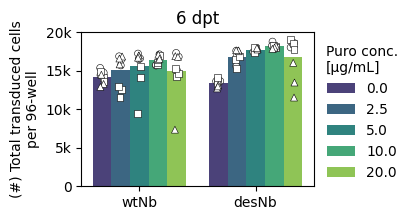

In [125]:
# General plotting params
x = 'cond'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['vDN193', 'vDN196']
label_map = {'vDN193':'wtNb', 'vDN196':'desNb'}

df_curr = count_df_reps.loc[(count_df_reps.cond == 'vDN193') | (count_df_reps.cond == 'vDN196')]
df_curr = df_curr.loc[df_curr.dpt == 6]

hue = 'puro'
hue_order = np.sort(count_df_reps[hue].unique())

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,
    order=order,
    palette="viridis", alpha=1)


# Plot tech reps
for (j, rep) in enumerate(df_curr.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.rep == rep)],
        x=x, y=y, hue=hue,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro:'white' for puro in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,)


 # Formatting
ax.yaxis.set_label_text('(#) Total transduced cells\nper 96-well')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 20e3))
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
    title=f'Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    
# Title
ax.set_title(f'6 dpt')
ax.set_xlabel('')

plt.savefig(figpath + f'bar_total-count_puro-ONLY.svg', bbox_inches='tight')


# Compare blast and bleo at 6 vs 10 dpt

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


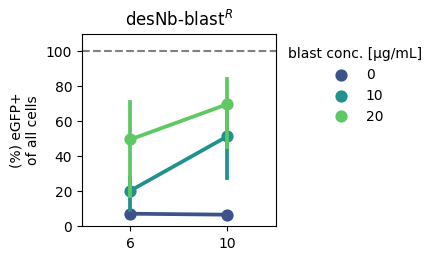

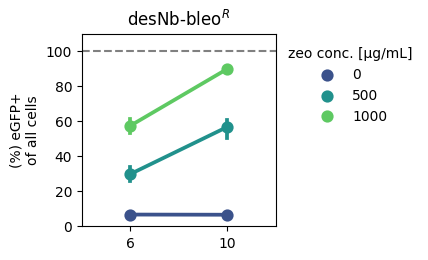

In [79]:
# General plotting params
x = 'dpt'
y = 'percent'

marker_list = ['o', 's', '^', 'D', 'P', 'X']   

antibiotic_map = {'vDN193':'puro', 'vDN194':'blast', 'vDN195':'zeo', 'vDN196':'puro'}
label_map = {'vDN193':'wtNb-puro$^R$', 'vDN194':'desNb-blast$^R$', 'vDN195':'desNb-bleo$^R$', 'vDN196':'desNb-puro$^R$'}


for cond in ['vDN194', 'vDN195']:

    curr_df = data_eGFP_percent_reps.loc[(data_eGFP_percent_reps.cond == cond)]

    hue = antibiotic_map[cond]
    hue_order = np.sort(curr_df[hue].unique())



    # What to plot
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))

    # Plot
    sns.pointplot(
        ax=ax, data=curr_df,
        x=x, y=y, hue=hue,
        palette="viridis")

    # # Plot tech reps
    # for (j, rep) in enumerate(curr_df.rep.unique()):
    #     sns.stripplot(
    #         ax=ax, data=curr_df[(curr_df.rep == rep)],
    #         x=x, y=y, hue=hue,
    #         dodge=True, marker=marker_list[j],
    #         palette={h:'white' for h in hue_order}, size=5,
    #         edgecolor='black', linewidth=0.4,)

    # Formatting
    ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
    ax.set_ylim((0, 110))
    
    h,l = ax.get_legend_handles_labels()
    sns.move_legend(ax, handles=h[:len(hue_order)], labels=l[:len(hue_order)],
        title=f'{hue} conc. [µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

    # Title
    ax.set_title(f'{label_map[cond]}')
    ax.axhline(100, 0, 1, color='grey', linestyle='--')
    ax.set_xlabel('')

    # plt.savefig(figpath + f'bar_EGFP-percent-vs-dpt_{cond}.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


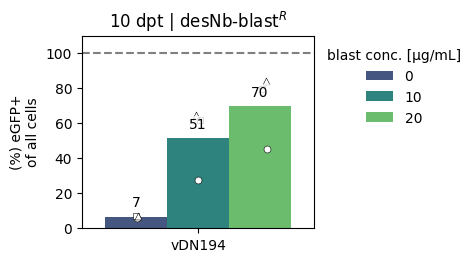

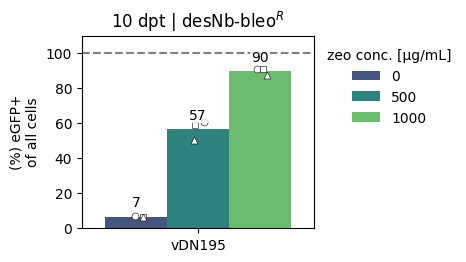

In [80]:
# General plotting params
x = 'cond'
y = 'percent'
dpt = 10
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

antibiotic_map = {'vDN193':'puro', 'vDN194':'blast', 'vDN195':'zeo', 'vDN196':'puro'}
label_map = {'vDN193':'wtNb-puro$^R$', 'vDN194':'desNb-blast$^R$', 'vDN195':'desNb-bleo$^R$', 'vDN196':'desNb-puro$^R$'}


for cond in data_eGFP_percent_reps.cond.unique():

    if (cond=='Ctrl-neg') | (cond=='Ctrl-EGFP') | (cond=='vDN193') | (cond=='vDN196'): continue

    curr_df = data_eGFP_percent_reps.loc[(data_eGFP_percent_reps.cond == cond) & (data_eGFP_percent_reps.dpt == dpt)]

    hue = antibiotic_map[cond]
    hue_order = np.sort(curr_df[hue].unique())
    

    # What to plot
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

    # Plot
    sns.barplot(
        ax=ax, data=curr_df,
        x=x, y=y, ci=None, hue=hue,
        palette="viridis", alpha=1)
    
    # Plot tech reps
    for (j, rep) in enumerate(curr_df.rep.unique()):
        sns.stripplot(
            ax=ax, data=curr_df[(curr_df.rep == rep)],
            x=x, y=y, hue=hue,
            dodge=True, marker=marker_list[j],
            palette={puro:'white' for puro in hue_order}, size=5,
            edgecolor='black', linewidth=0.4,)

    # Formatting
    ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
    ax.set_ylim((0, 110))
    h,l = ax.get_legend_handles_labels()
    sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
        title=f'{hue} conc. [µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    # Title
    ax.set_title(f'{dpt} dpt | {label_map[cond]}')
    ax.axhline(100, 0, 1, color='grey', linestyle='--')
    ax.set_xlabel('')
    # Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
    
    # plt.savefig(figpath + f'bar_EGFP-percent_{cond}_{dpt}dpt.svg', bbox_inches='tight')

### Final blast/bleo/puroR plot

/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_351/3459561104.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_curr.loc[(df_curr['blast'] == 0) & (df_curr['cond'] == 'vDN194') & (df_curr['dpt'] == 10), 'anti_cat'] = '0'
/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


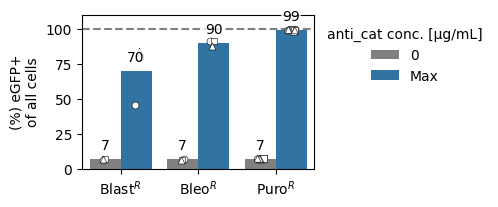

In [83]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['vDN194', 'vDN195', 'vDN196']

antibiotic_map = {'vDN194':'blast', 'vDN195':'zeo', 'vDN196':'puro'}
label_map = {'vDN194':'Blast$^R$', 'vDN195':'Bleo$^R$', 'vDN196':'Puro$^R$'}

# Just get desNb's ['vDN194', 'vDN195', 'vDN196']
df_curr = data_eGFP_percent_reps.loc[data_eGFP_percent_reps.cond.isin(order)]

# Split into 0 or max
# For blast and zeo, use 10 dpt
df_curr.loc[(df_curr['blast'] == 0) & (df_curr['cond'] == 'vDN194') & (df_curr['dpt'] == 10), 'anti_cat'] = '0'
df_curr.loc[(df_curr['blast'] == 20) & (df_curr['cond'] == 'vDN194') & (df_curr['dpt'] == 10), 'anti_cat'] = 'Max'

df_curr.loc[(df_curr['zeo'] == 0) & (df_curr['cond'] == 'vDN195') & (df_curr['dpt'] == 10), 'anti_cat'] = '0'
df_curr.loc[(df_curr['zeo'] == 1000) & (df_curr['cond'] == 'vDN195') & (df_curr['dpt'] == 10), 'anti_cat'] = 'Max'

df_curr.loc[(df_curr['puro'] == 0) & (df_curr['cond'] == 'vDN196'), 'anti_cat'] = '0'
df_curr.loc[(df_curr['puro'] == 20) & (df_curr['cond'] == 'vDN196'), 'anti_cat'] = 'Max'

hue = 'anti_cat'
hue_order = ['0', 'Max']
palette = {'0':'grey', 'Max':'tab:blue'}

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot tech reps
for (j, rep) in enumerate(df_curr.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,)
    
 
# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 110))
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
    title=f'{hue} conc. [µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels(label_map[l] for l in order)

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))


# plt.savefig(figpath + f'bar_EGFP-percent_0-Max.svg', bbox_inches='tight')